In [1]:
import brott

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u

pd.set_option('display.max_columns', None)

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = "retina"

In [2]:
models = pd.read_csv("/mnt/ceph/users/twagg/dr1/brott2011_evol/models.dat", header=None, names=["mass", "v_rot", "gal", "filename"], sep="\s+")
lifetimes = np.zeros(len(models))
f_crit = np.zeros(len(models))

In [4]:
df

,m_init,v_zams,galaxy,t,Mass,Teff,logL,R,log(Mdot),logg,Vsurf,Prot,Vcrit,Ge,eps(H),eps(He),eps(Li),eps(Be),eps(B),eps(C),eps(N),eps(O),eps(F),eps(Ne),eps(Na),eps(Mg),eps(Al),eps(Si),eps(Fe),sH1,sHe3,sHe4,sLi7,sBe9,sB10,sB11,sC12,sC13,sN14,sN15,sO16,sO17,sO18,sF19,sNe20,sNe21,sNe22,sNa23,sMg24,sMg25,sMg26,sAl26,sAl27,sSi28,sSi29,sSi30,sFe56,cH1,cHe3,cHe4,cLi7,cBe9,cB10,cB11,cC12,cC13,cN14,cN15,cO16,cO17,cO18,cF19,cNe20,cNe21,cNe22,cNa23,cMg24,cMg25,cMg26,cAl26,cAl27,cSi28,cSi29,cSi30,cFe56
0,9,301,smc,0.0,8.99993,26149.17384,3.61638,3.13058,-10.22400,4.40071,300.56923,0.52741,735.8470,0.01228,12.0,10.92544,1.93079,0.45648,1.98350,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,4.391570e-10,1.921850e-11,1.461500e-10,6.297240e-10,0.000208,0.000003,0.000033,1.297000e-07,0.001138,4.508170e-07,2.566790e-06,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.000010,0.000011,5.909350e-15,0.000009,0.000122,0.000006,0.000004,0.000252,7.311390e-01,1.364580e-06,0.267301,1.013910e-16,1.737800e-23,1.389950e-19,5.970350e-20,0.000009,2.837920e-06,0.000910,3.556310e-08,0.000344,0.000064,3.206270e-10,1.972420e-09,0.000191,2.910720e-07,0.000002,0.000020,0.000074,0.000006,0.000013,1.603250e-06,0.000010,0.000122,0.000006,0.000004,0.000252
1,9,301,smc,153616.0,8.99992,26130.62747,3.61813,3.14135,-10.22260,4.39773,300.31739,0.52967,734.5660,0.01233,12.0,10.92544,1.84581,0.41205,1.97575,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,3.618850e-10,1.734960e-11,1.450240e-10,6.169780e-10,0.000208,0.000003,0.000033,1.297000e-07,0.001138,4.508170e-07,2.566790e-06,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.000010,0.000011,2.259700e-14,0.000009,0.000122,0.000006,0.000004,0.000252,7.294580e-01,1.355190e-06,0.269153,1.018590e-16,1.282330e-23,1.088930e-19,4.634470e-20,0.000009,2.844460e-06,0.000935,3.664380e-08,0.000318,0.000060,2.648500e-10,1.798870e-09,0.000191,2.937650e-07,0.000002,0.000020,0.000074,0.000006,0.000013,1.566750e-06,0.000010,0.000122,0.000006,0.000004,0.000252
2,9,301,smc,304999.0,8.99991,26116.79808,3.61984,3.15089,-10.22020,4.39510,300.16316,0.53155,733.4350,0.01238,12.0,10.92544,1.76239,0.36822,1.96696,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,2.991850e-10,1.568410e-11,1.436380e-10,6.029340e-10,0.000208,0.000003,0.000033,1.297000e-07,0.001138,4.508370e-07,2.566790e-06,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.000010,0.000011,6.523790e-14,0.000009,0.000122,0.000006,0.000004,0.000252,7.261060e-01,1.327390e-06,0.271644,1.028020e-16,7.277800e-24,6.729770e-20,2.824880e-20,0.000009,2.831390e-06,0.000959,3.758370e-08,0.000293,0.000057,1.892340e-10,1.524050e-09,0.000191,2.958010e-07,0.000001,0.000021,0.000074,0.000006,0.000014,1.527570e-06,0.000010,0.000122,0.000006,0.000004,0.000252
3,9,301,smc,453631.0,8.99990,26107.06805,3.62153,3.15938,-10.21750,4.39276,300.09103,0.53311,732.4300,0.01242,12.0,10.92544,1.68063,0.32516,1.95737,7.37001,6.50002,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,2.482220e-10,1.420370e-11,1.420330e-10,5.880850e-10,0.000208,0.000003,0.000033,1.297030e-07,0.001138,4.508790e-07,2.566730e-06,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.000010,0.000011,1.550140e-13,0.000009,0.000122,0.000006,0.000004,0.000252,7.244360e-01,1.306170e-06,0.273527,1.047130e-16,4.518560e-24,4.634470e-20,1.901080e-20,0.000009,2.818380e-06,0.000979,3.854780e-08,0.000272,0.000054,1.513560e-10,1.330450e-09,0.000191,2.978520e-07,0.000001,0.000021,0.000074,0.000006,0.000014,1.475710e-06,0.000010,0.000122,0.000006,0.000004,0.000252
4,9,301,smc,599245.0,8.99989,26098.38351,3.62318,3.16749,-10.21440,4.39053,300.03798,0.53458,731.4740,0.01247,12.0,10.92544,1.60050,0.28294,1.94716,7.37000,6.50004,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.7

In [3]:
for i, row in models.iterrows():
    df = brott.read_track_dataframe("/mnt/ceph/users/twagg/dr1/brott2011_evol/", row["mass"], row["v_rot"], row["gal"])
    f_crit[i] = df["Vsurf"].values[0] / df["Vcrit"].values[0]
    noH1 = df["cH1"] < 1e-3
    if np.any(noH1):
        lifetimes[i] = df[noH1]["t"].values[0]
        print(f"Model {i} reached end of H-burning at t = {lifetimes[i] / 1e6:.2f} Myr")
    else:
        print(f"Model {i} did not reach end of H-burning it seems")
        lifetimes[i] = df["t"].values[-1]

Model 0 reached end of H-burning at t = 83.59 Myr
Model 1 reached end of H-burning at t = 93.20 Myr
Model 2 reached end of H-burning at t = 77.99 Myr
Model 3 reached end of H-burning at t = 93.78 Myr
Model 4 reached end of H-burning at t = 83.09 Myr
Model 5 reached end of H-burning at t = 76.70 Myr
Model 6 reached end of H-burning at t = 94.47 Myr
Model 7 reached end of H-burning at t = 83.60 Myr
Model 8 reached end of H-burning at t = 77.77 Myr
Model 9 reached end of H-burning at t = 95.42 Myr
Model 10 reached end of H-burning at t = 84.32 Myr
Model 11 reached end of H-burning at t = 78.12 Myr
Model 12 reached end of H-burning at t = 96.90 Myr
Model 13 reached end of H-burning at t = 85.78 Myr
Model 14 reached end of H-burning at t = 79.42 Myr
Model 15 reached end of H-burning at t = 97.98 Myr
Model 16 reached end of H-burning at t = 86.37 Myr
Model 17 reached end of H-burning at t = 81.12 Myr
Model 18 reached end of H-burning at t = 100.67 Myr
Model 19 reached end of H-burning at t =

KeyboardInterrupt: 

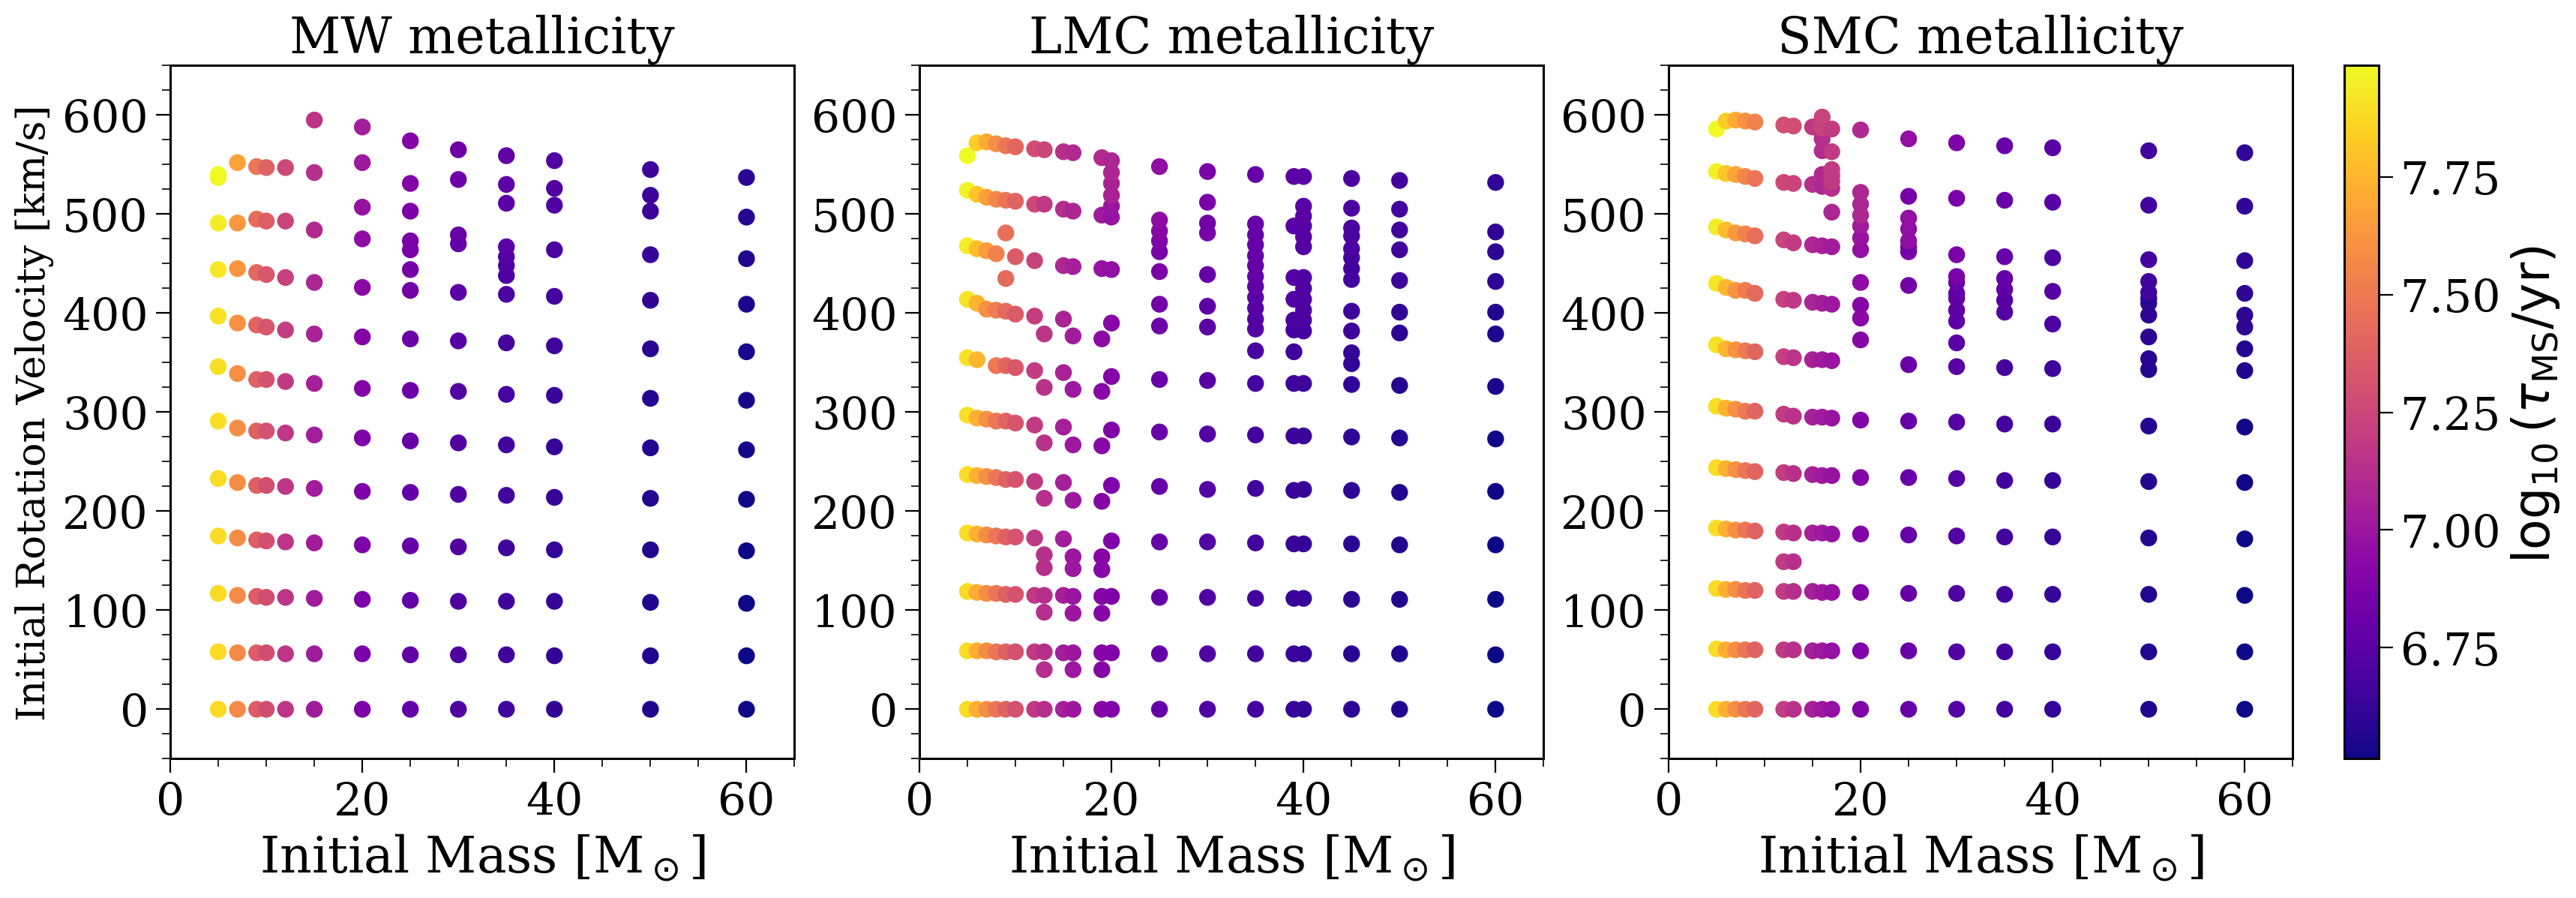

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for gal, ax in zip(["mw", "lmc", "smc"], axes):
    mask = models["gal"] == gal
    scatter = ax.scatter(models["mass"][mask], models["v_rot"][mask], c=np.log10(lifetimes[mask]), cmap="plasma", s=50)
    ax.set_title(f"{gal.upper()} metallicity", fontsize=fs)

cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label(r" $\log_{10}(\tau_{\rm MS} / {\rm yr})$")

for ax in axes:
    ax.set(
        xlabel="Initial Mass [M$_\odot$]",
        xlim=(0, 65),
        ylim=(-50, 650),
    )
    ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(25))

axes[0].set_ylabel("Initial Rotation Velocity [km/s]", fontsize=0.8 * fs)

plt.show()

8.082289776589395
8.01958980801014
7.986559460145124


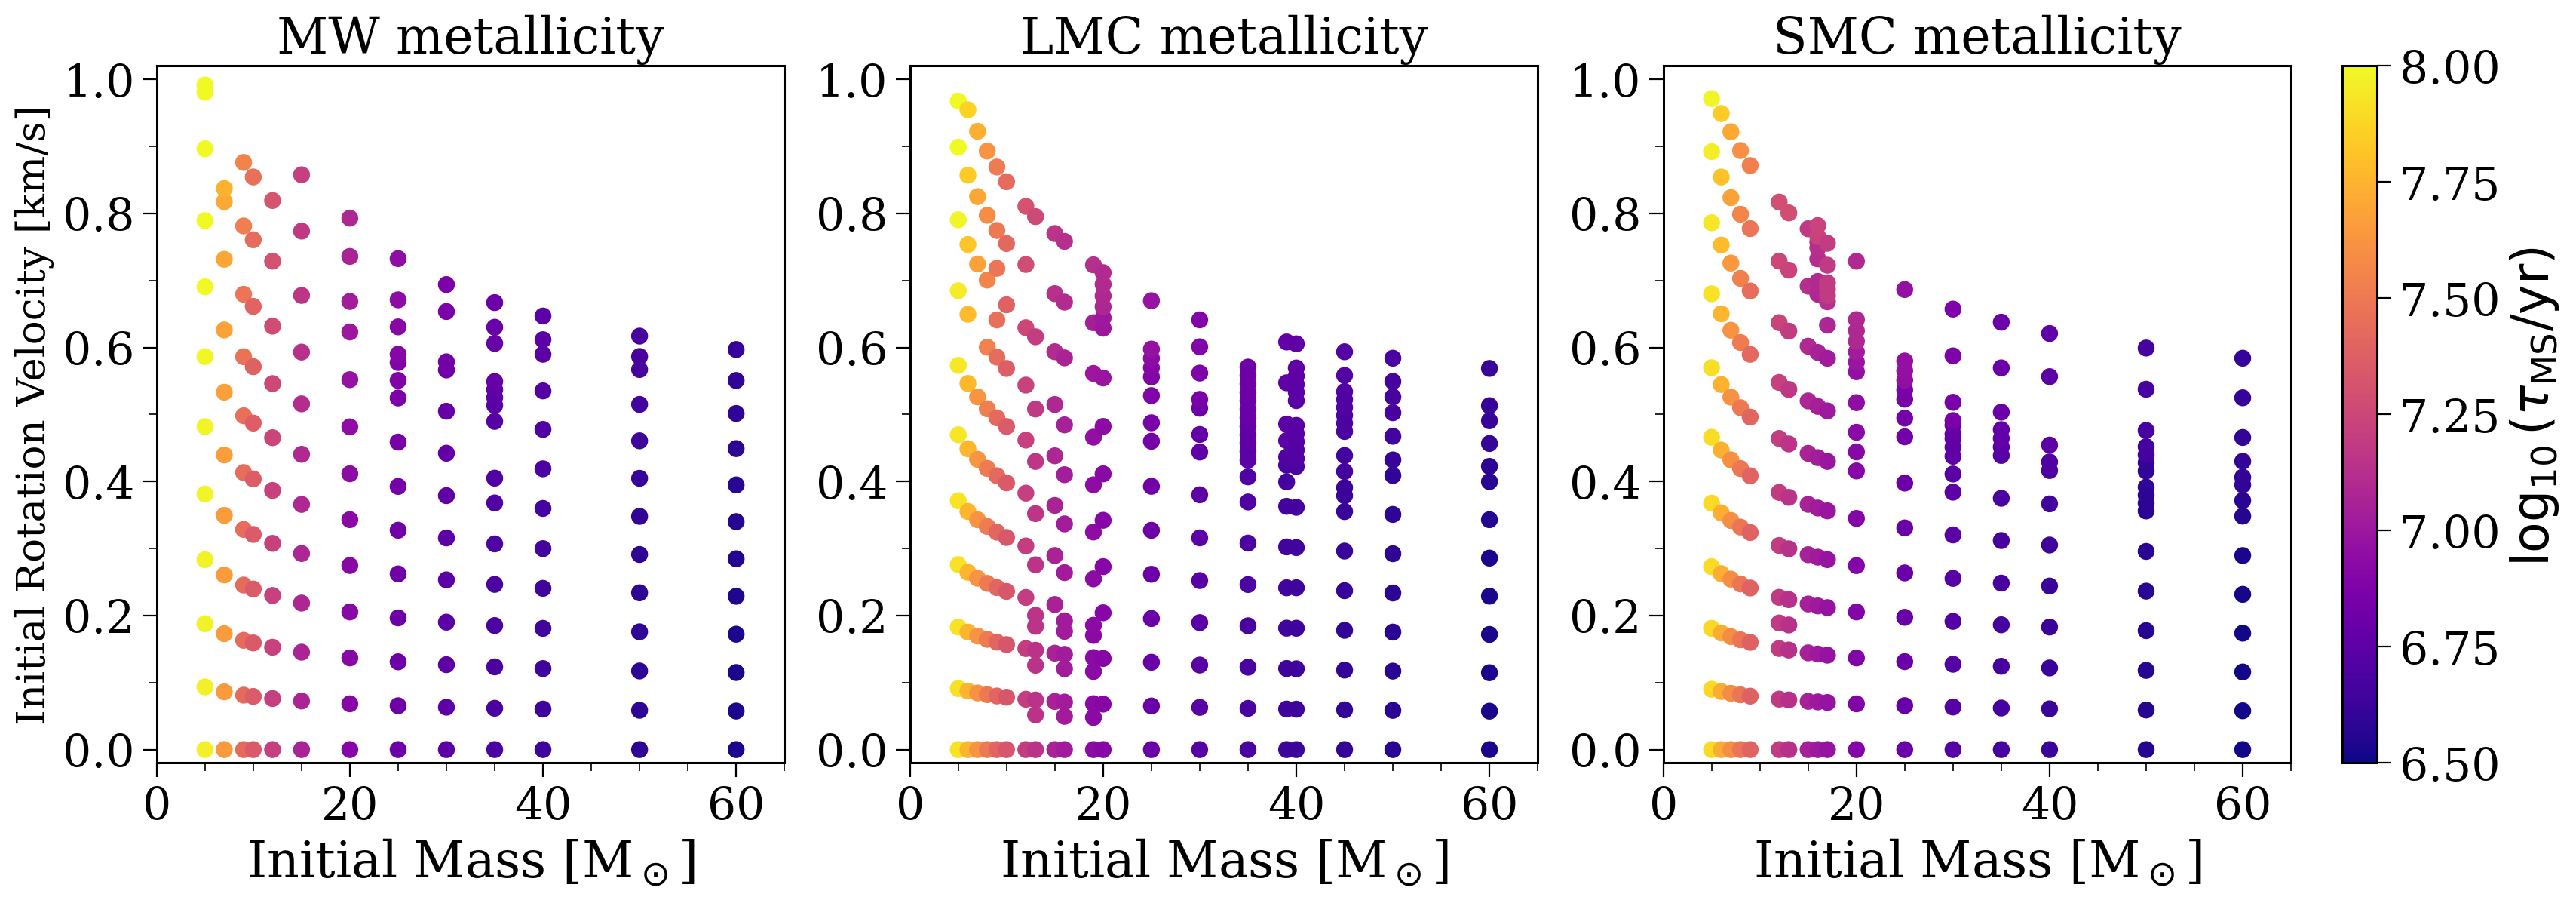

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

models["f_crit"] = f_crit

for gal, ax in zip(["mw", "lmc", "smc"], axes):
    mask = models["gal"] == gal
    print(np.log10(lifetimes[mask]).max())
    scatter = ax.scatter(models["mass"][mask], models["f_crit"][mask],
                         c=np.log10(lifetimes[mask]), cmap="plasma", s=50,
                         vmin=6.5, vmax=8.0)
    ax.set_title(f"{gal.upper()} metallicity", fontsize=fs)

cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label(r" $\log_{10}(\tau_{\rm MS} / {\rm yr})$")

for ax in axes:
    ax.set(
        xlabel="Initial Mass [M$_\odot$]",
        xlim=(0, 65),
        ylim=(-0.02, 1.02),
    )
    ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.1))

axes[0].set_ylabel("Initial Rotation Velocity [km/s]", fontsize=0.8 * fs)

plt.show()

8.082289776589395
8.01958980801014
7.986559460145124


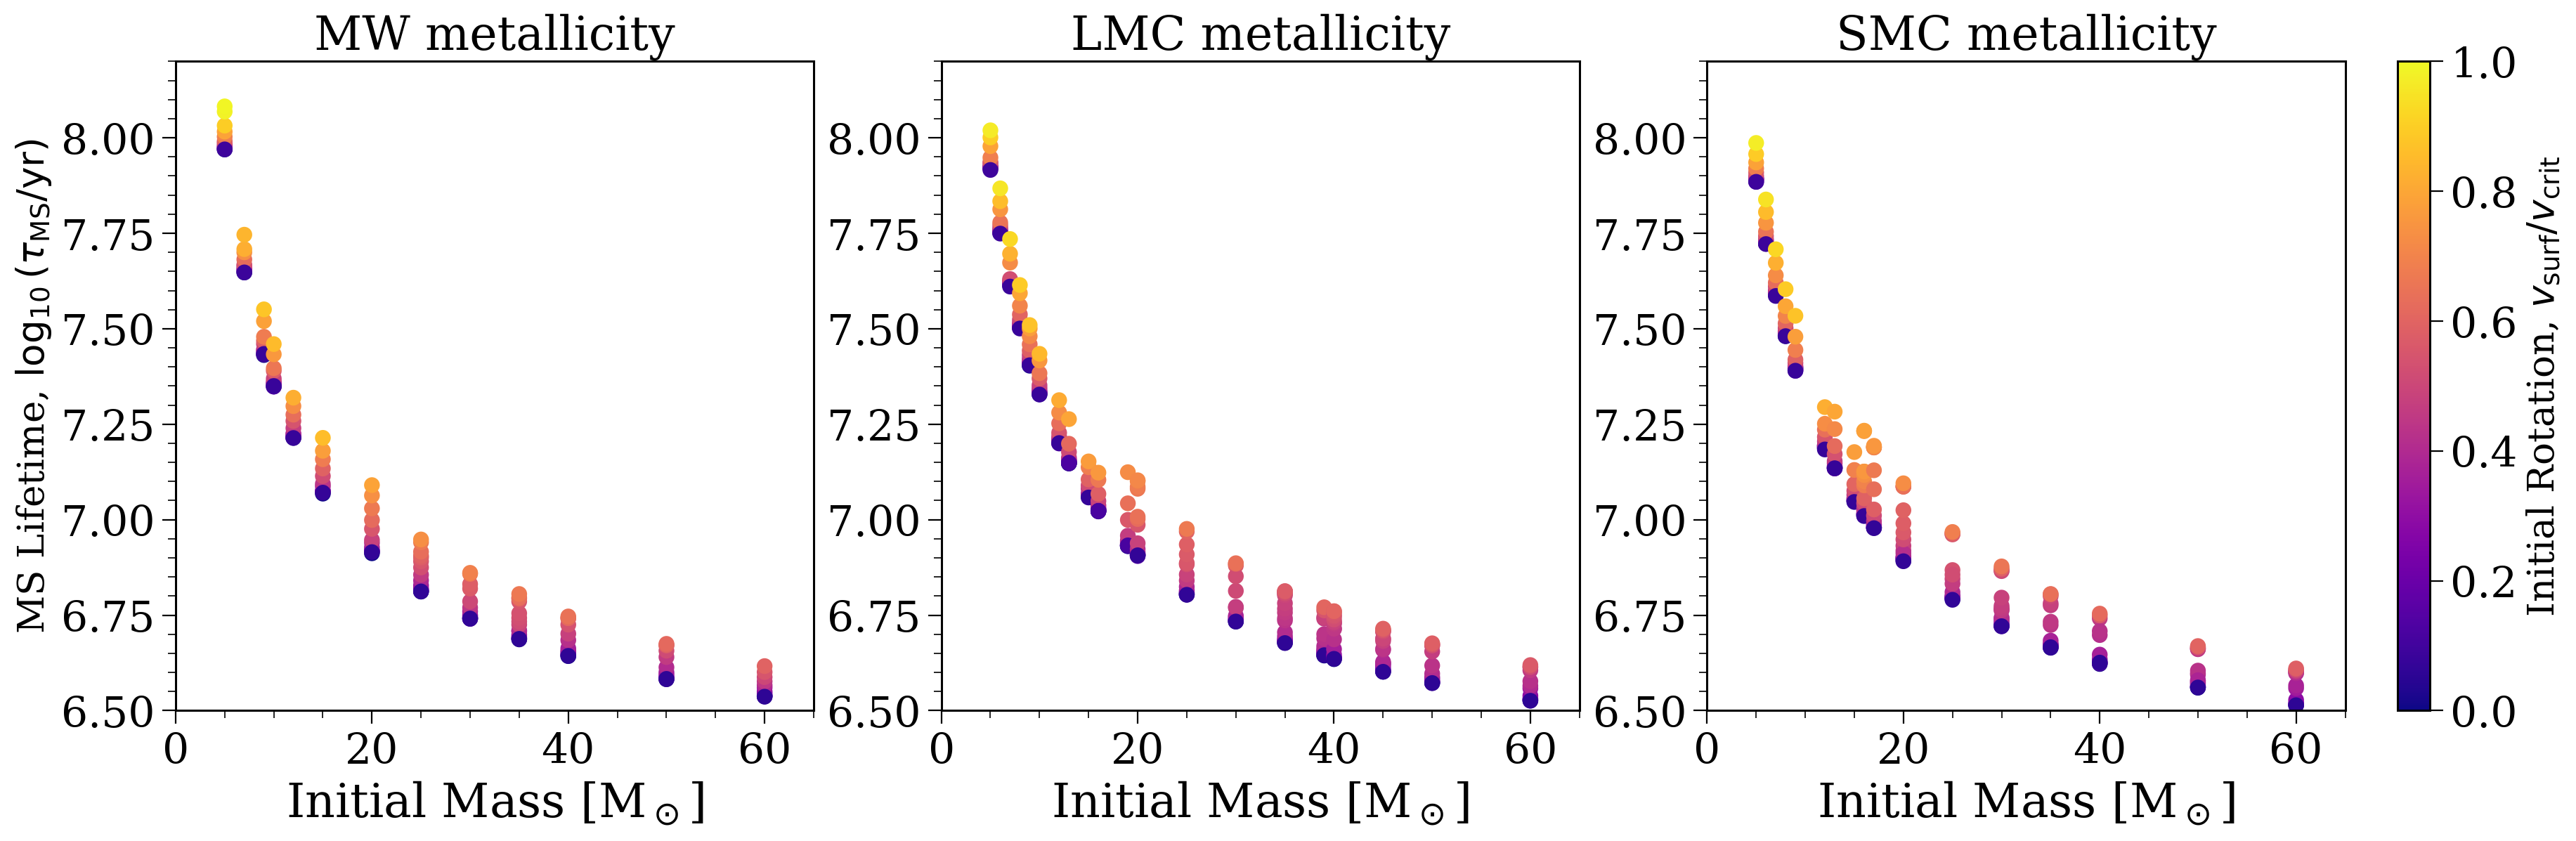

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

models["f_crit"] = f_crit

for gal, ax in zip(["mw", "lmc", "smc"], axes):
    mask = models["gal"] == gal
    print(np.log10(lifetimes[mask]).max())
    scatter = ax.scatter(models["mass"][mask], np.log10(lifetimes[mask]),
                         c=models["f_crit"][mask], cmap="plasma", s=50,
                         vmin=0, vmax=1.0)
    ax.set_title(f"{gal.upper()} metallicity", fontsize=fs)

cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label(r"Initial Rotation, $v_{\rm surf} / v_{\rm crit}$", fontsize=0.8*fs)

for ax in axes:
    ax.set(
        xlabel="Initial Mass [M$_\odot$]",
        xlim=(0, 65),
        ylim=(6.5, 8.2)
    )
    ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

axes[0].set_ylabel(r"MS Lifetime, $\log_{10}(\tau_{\rm MS} / {\rm yr})$", fontsize=0.8 * fs)

plt.show()

f_crit
0.000000    50
0.509353     1
0.518139     1
0.566444     1
0.578549     1
            ..
0.145351     1
0.143853     1
0.144350     1
0.218608     1
0.715323     1
Name: count, Length: 614, dtype: int64

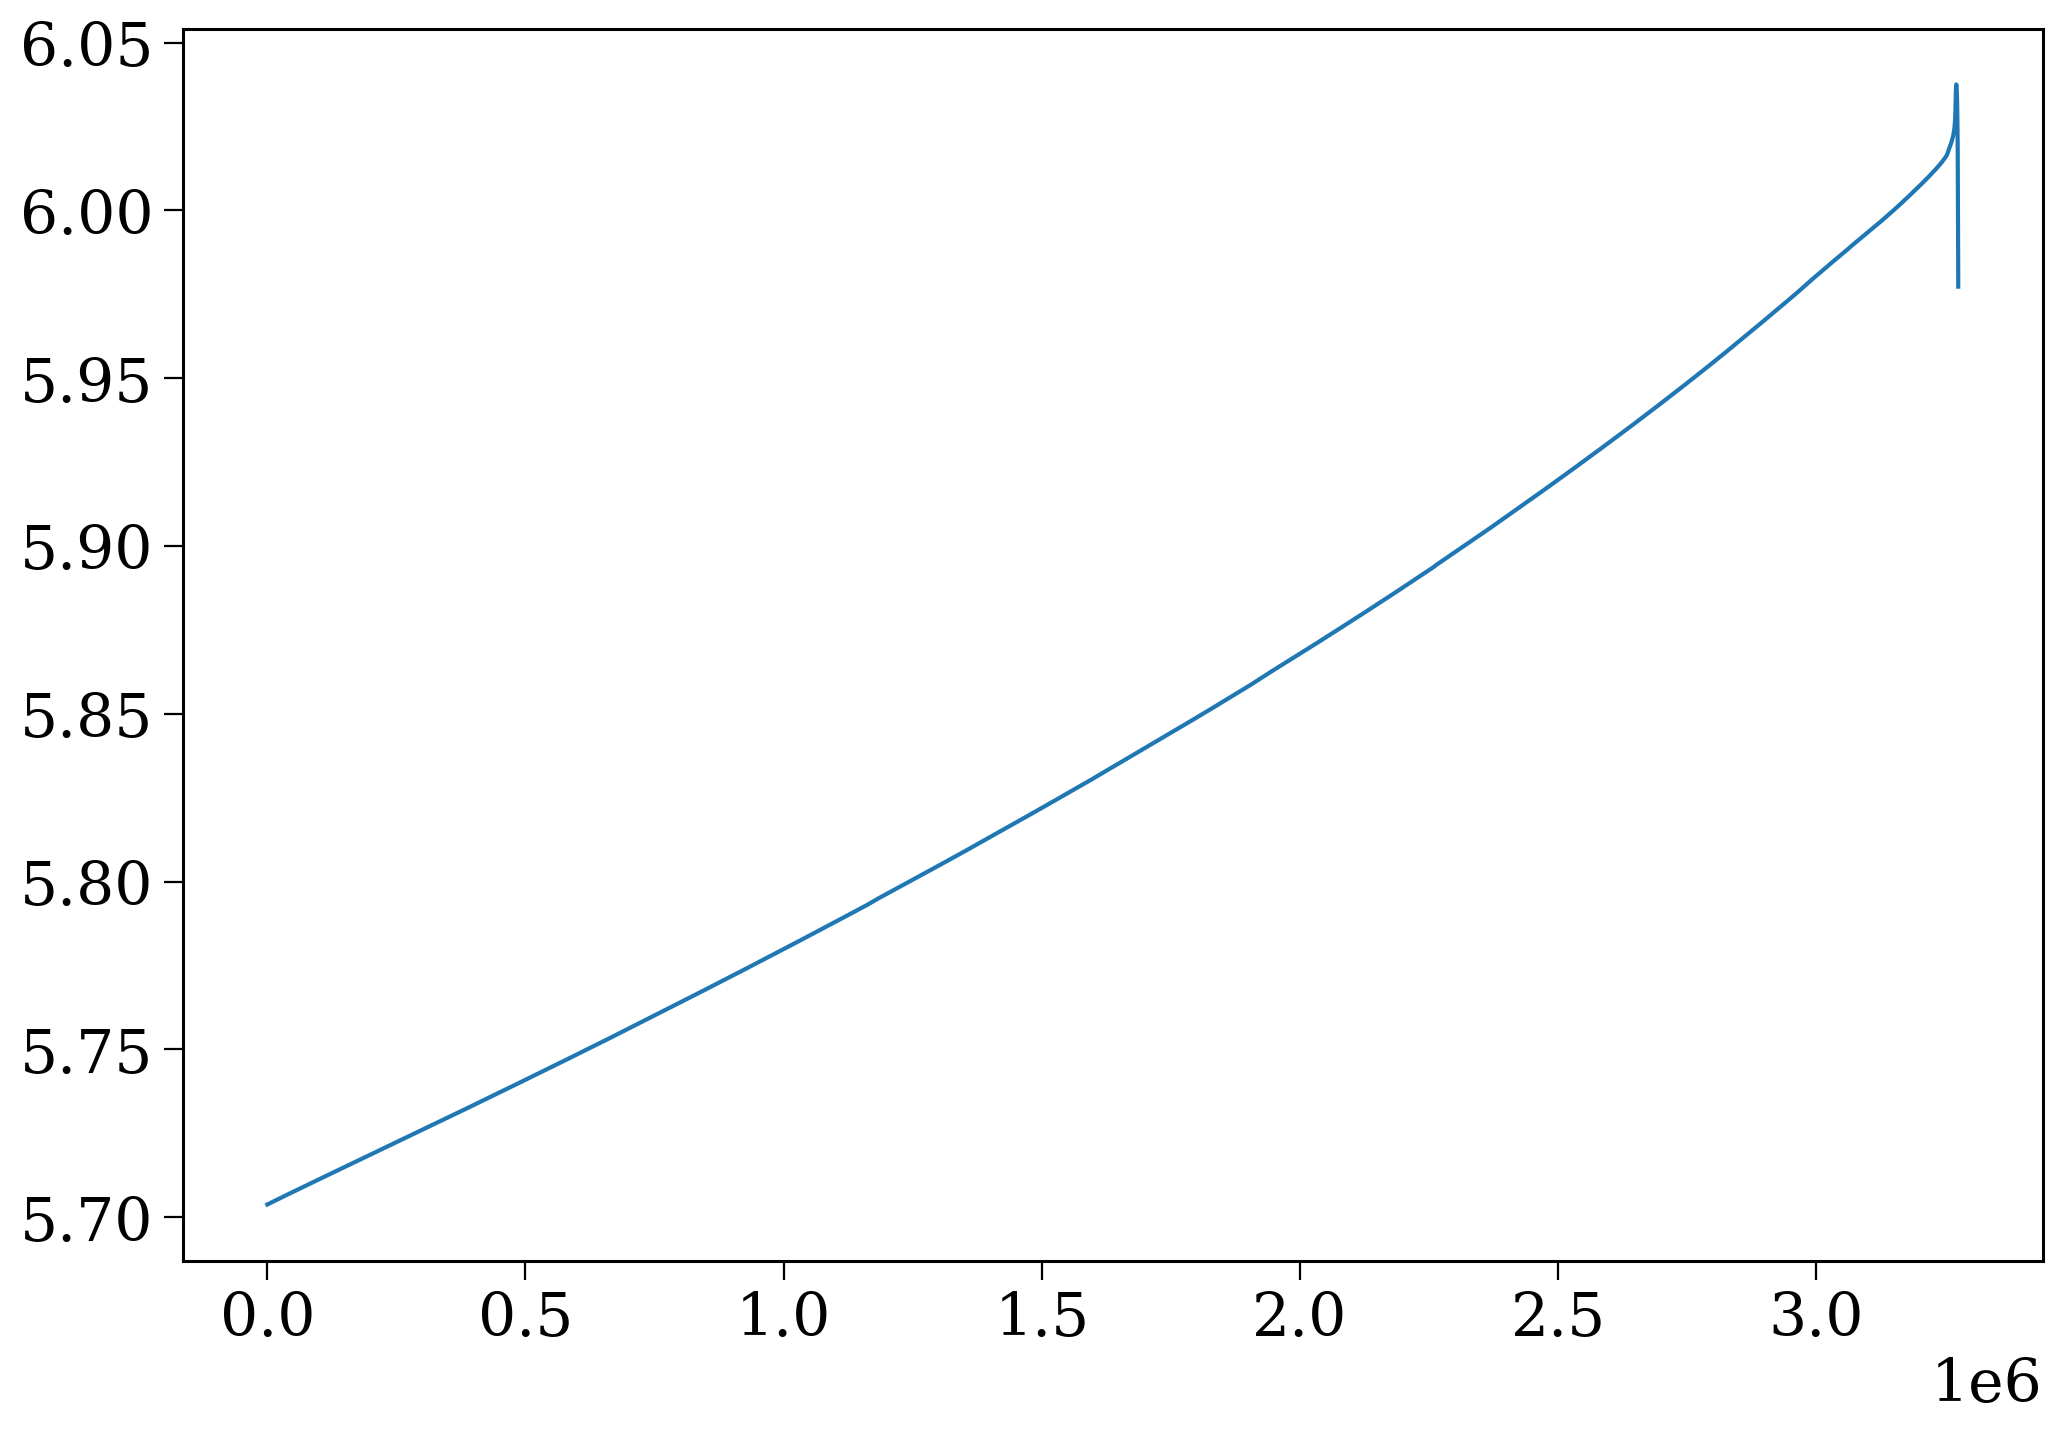

In [53]:
plt.plot(df["t"], df["logL"])

7.986559460145124


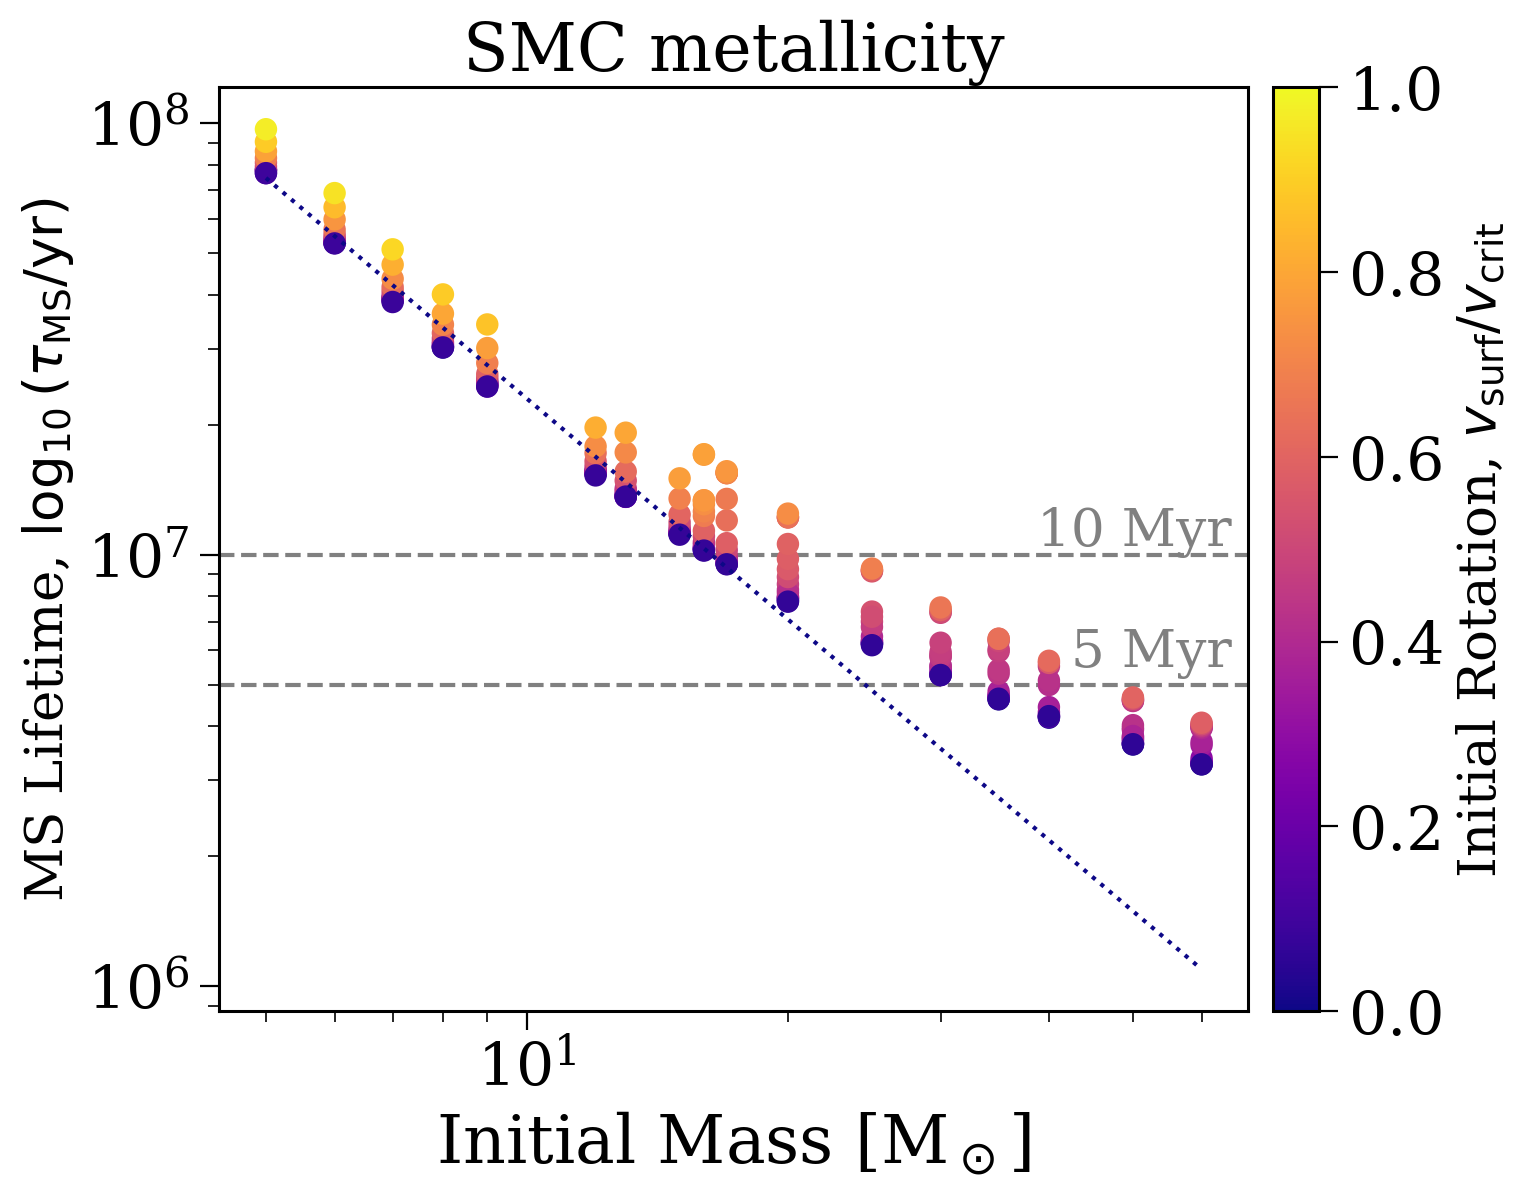

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))

models["f_crit"] = f_crit
gal = "smc"

mask = models["gal"] == gal
print(np.log10(lifetimes[mask]).max())
scatter = ax.scatter(models["mass"][mask], lifetimes[mask],
                     c=models["f_crit"][mask], cmap="plasma", s=50,
                     vmin=0, vmax=1.0)
ax.set_title(f"{gal.upper()} metallicity", fontsize=fs)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label(r"Initial Rotation, $v_{\rm surf} / v_{\rm crit}$", fontsize=0.8*fs)

power_law_guess = -1.7
m_range = np.linspace(5, 60, 1000)
ax.plot(m_range, 2.3e7 * (m_range / 10)**power_law_guess, color=plt.get_cmap("plasma")(0.0), linestyle="dotted", label=f"Power-law: t ~ M^{{{power_law_guess}}}")

for line in [5, 10]:
    ax.axhline(line * 1e6, color="gray", linestyle="--", zorder=-1)
    ax.annotate(f"{line} Myr", xy=(65, line * 1e6 + 0.5e6), color="gray", fontsize=0.8 * fs, ha="right")

ax.set(
    xlabel="Initial Mass [M$_\odot$]",
    # xlim=(0, 65),
    # ylim=(6.5, 8.2)
    yscale="log",
    xscale="log"
)
# ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
# ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.set_ylabel(r"MS Lifetime, $\log_{10}(\tau_{\rm MS} / {\rm yr})$", fontsize=0.8 * fs)

plt.show()

0.7286589528810166


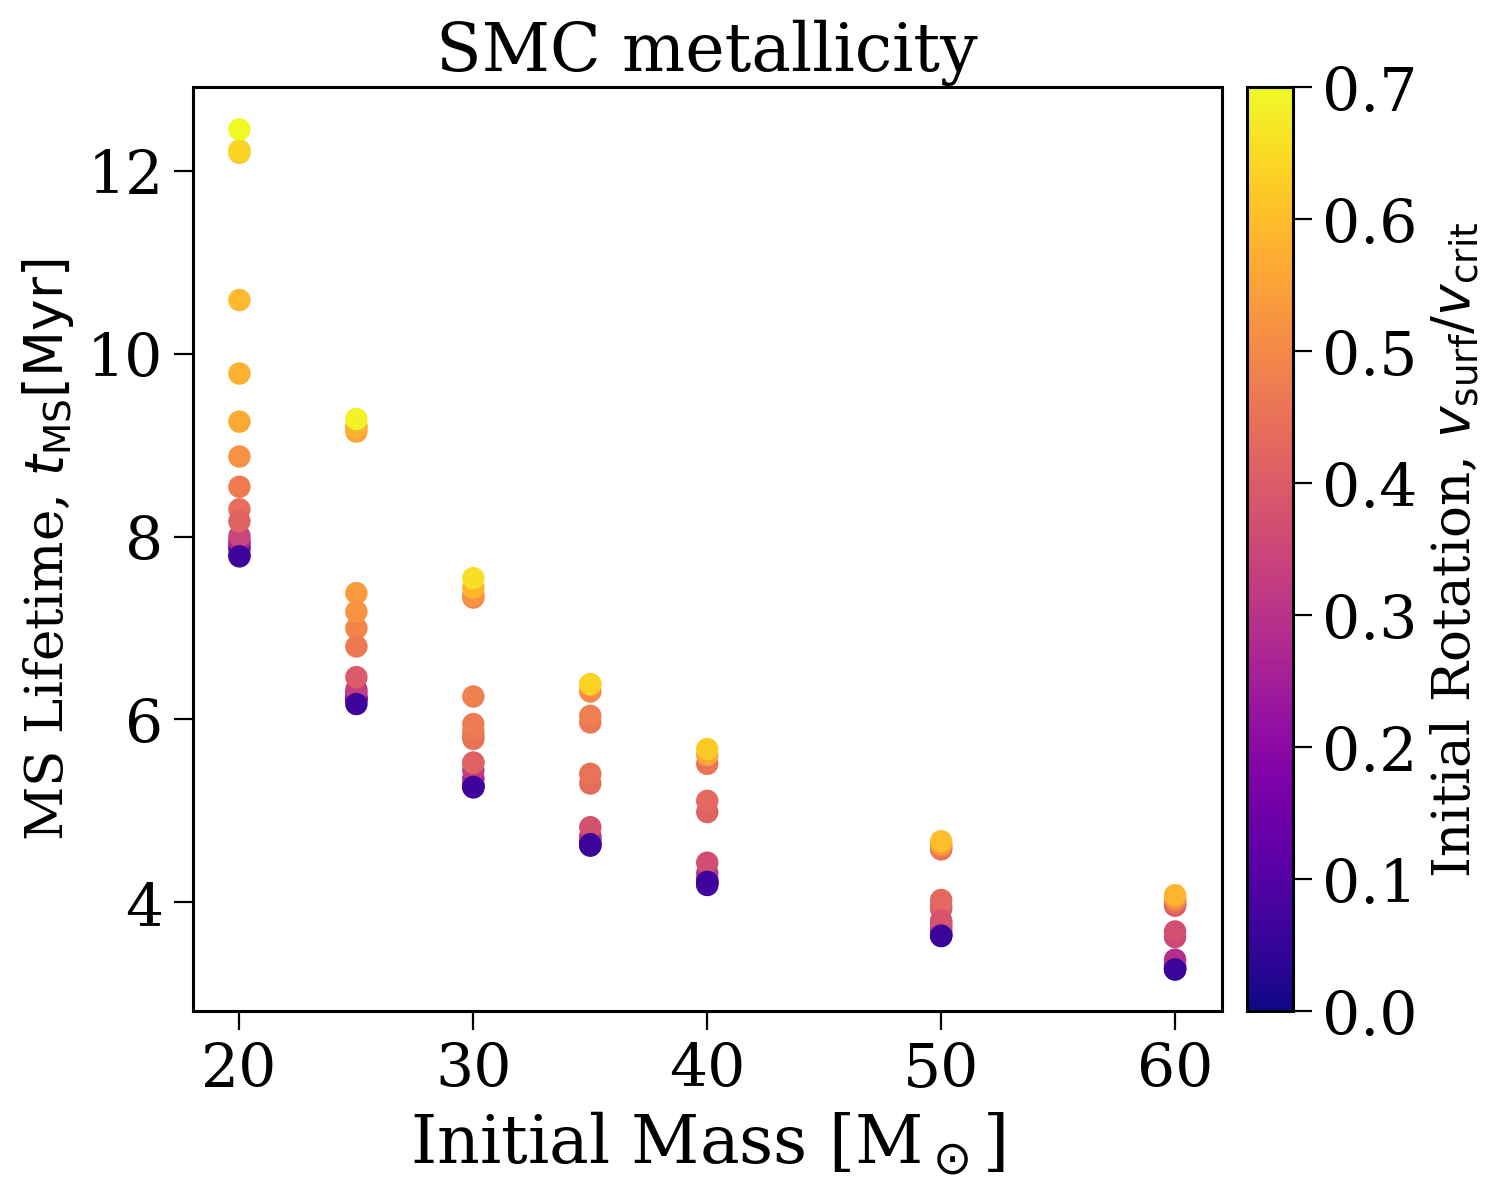

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

models["f_crit"] = f_crit
gal = "smc"

mask = models["gal"] == gal
mask &= (models["mass"] >= 20)
print(models["f_crit"][mask].max())
scatter = ax.scatter(models["mass"][mask], lifetimes[mask] / 1e6,
                     c=models["f_crit"][mask], cmap="plasma", s=50,
                     vmin=0, vmax=0.7)
ax.set_title(f"{gal.upper()} metallicity", fontsize=fs)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label(r"Initial Rotation, $v_{\rm surf} / v_{\rm crit}$", fontsize=0.8*fs)

ax.set(
    xlabel="Initial Mass [M$_\odot$]",
    # xlim=(0, 65),
    # ylim=(6.5, 8.2)
    # yscale="log",
    # xscale="log"
)
# ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
# ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.set_ylabel(r"MS Lifetime, $t_{\rm MS} [{\rm Myr}]$", fontsize=0.8 * fs)

plt.show()

In [116]:
df

,m_init,v_zams,galaxy,t,Mass,Teff,logL,R,log(Mdot),logg,Vsurf,Prot,Vcrit,Ge,eps(H),eps(He),eps(Li),eps(Be),eps(B),eps(C),eps(N),eps(O),eps(F),eps(Ne),eps(Na),eps(Mg),eps(Al),eps(Si),eps(Fe),sH1,sHe3,sHe4,sLi7,sBe9,sB10,sB11,sC12,sC13,sN14,sN15,sO16,sO17,sO18,sF19,sNe20,sNe21,sNe22,sNa23,sMg24,sMg25,sMg26,sAl26,sAl27,sSi28,sSi29,sSi30,sFe56,cH1,cHe3,cHe4,cLi7,cBe9,cB10,cB11,cC12,cC13,cN14,cN15,cO16,cO17,cO18,cF19,cNe20,cNe21,cNe22,cNa23,cMg24,cMg25,cMg26,cAl26,cAl27,cSi28,cSi29,cSi30,cFe56
0,60,58,smc,0.0,59.94560,51451.47728,5.70379,8.94242,-6.29725,4.31257,57.59269,7.862310e+00,995.0500,0.22543,12.0,10.92544,2.54439,0.67998,2.00000,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,1.705340e-09,3.215290e-11,1.479480e-10,6.583550e-10,0.000208,0.000003,0.000033,1.296970e-07,0.001138,4.508170e-07,0.000003,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.00001,0.000011,1.996600e-16,0.000009,0.000122,0.000006,0.000004,0.000252,7.311390e-01,1.122020e-07,0.267301,1.321300e-17,1.000000e-99,4.920400e-59,3.990250e-32,0.000013,4.159110e-06,0.001021,3.926450e-08,0.000248,0.000021,1.161450e-10,8.851160e-11,0.000190,2.773320e-08,0.000012,0.000011,0.000074,0.000005,0.000011,3.962780e-06,0.000011,0.000122,0.000006,0.000004,0.000252
1,60,58,smc,0.0,59.94560,51451.47728,5.70379,8.94242,-6.29725,4.31257,57.59269,7.862310e+00,995.0500,0.22543,12.0,10.92544,2.54439,0.67998,2.00000,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,1.705340e-09,3.215290e-11,1.479480e-10,6.583550e-10,0.000208,0.000003,0.000033,1.296970e-07,0.001138,4.508170e-07,0.000003,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.00001,0.000011,1.996600e-16,0.000009,0.000122,0.000006,0.000004,0.000252,7.311390e-01,1.122020e-07,0.267301,1.321300e-17,1.000000e-99,4.920400e-59,3.990250e-32,0.000013,4.159110e-06,0.001021,3.926450e-08,0.000248,0.000021,1.161450e-10,8.851160e-11,0.000190,2.773320e-08,0.000012,0.000011,0.000074,0.000005,0.000011,3.962780e-06,0.000011,0.000122,0.000006,0.000004,0.000252
2,60,58,smc,11713.6,59.93966,51418.41379,5.70469,8.96313,-6.29475,4.31052,57.56839,7.883850e+00,993.5390,0.22591,12.0,10.92544,2.54163,0.67994,2.00000,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,1.699500e-09,3.214990e-11,1.479480e-10,6.583550e-10,0.000208,0.000003,0.000033,1.296970e-07,0.001138,4.508170e-07,0.000003,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.00001,0.000011,1.974150e-16,0.000009,0.000122,0.000006,0.000004,0.000252,7.294580e-01,1.101540e-07,0.269153,1.455460e-17,1.377210e-70,3.622430e-48,3.908410e-32,0.000013,4.197590e-06,0.001042,4.008670e-08,0.000225,0.000020,9.705100e-11,5.662390e-11,0.000190,2.792540e-08,0.000011,0.000012,0.000074,0.000004,0.000011,4.149540e-06,0.000011,0.000122,0.000006,0.000004,0.000252
3,60,58,smc,23295.8,59.93375,51387.80975,5.70556,8.98286,-6.29232,4.30857,57.54297,7.904700e+00,992.0920,0.22639,12.0,10.92544,2.53821,0.67988,2.00000,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.000031,0.251437,1.691140e-09,3.214550e-11,1.479480e-10,6.583550e-10,0.000208,0.000003,0.000033,1.296970e-07,0.001138,4.508170e-07,0.000003,1.027450e-07,0.000192,4.821030e-07,0.000015,0.000005,0.000074,0.00001,0.000011,1.952180e-16,0.000009,0.000122,0.000006,0.000004,0.000252,7.277800e-01,1.086430e-07,0.271019,1.531090e-17,3.741110e-54,7.798300e-40,3.854780e-32,0.000013,4.226690e-06,0.001062,4.073800e-08,0.000206,0.000018,8.317640e-11,3.672820e-11,0.000190,2.805430e-08,0.000011,0.000012,0.000074,0.000004,0.000011,4.305270e-06,0.000011,0.000122,0.000006,0.000004,0.000252
4,60,58,smc,34762.3,59.92787,51359.36752,5.70643,9.00177,-6.28996,4.30670,57.53446,7.922520e+00,990.6970,0.22687,12.0,10.92544,2.53384,0.67977,2.00000,7.37001,6.50001,7.98000,3.86001,7.14000,5.47000,6.72001,5.67001,6.80000,6.78000,0.746449,0.

<Axes: xlabel='t'>

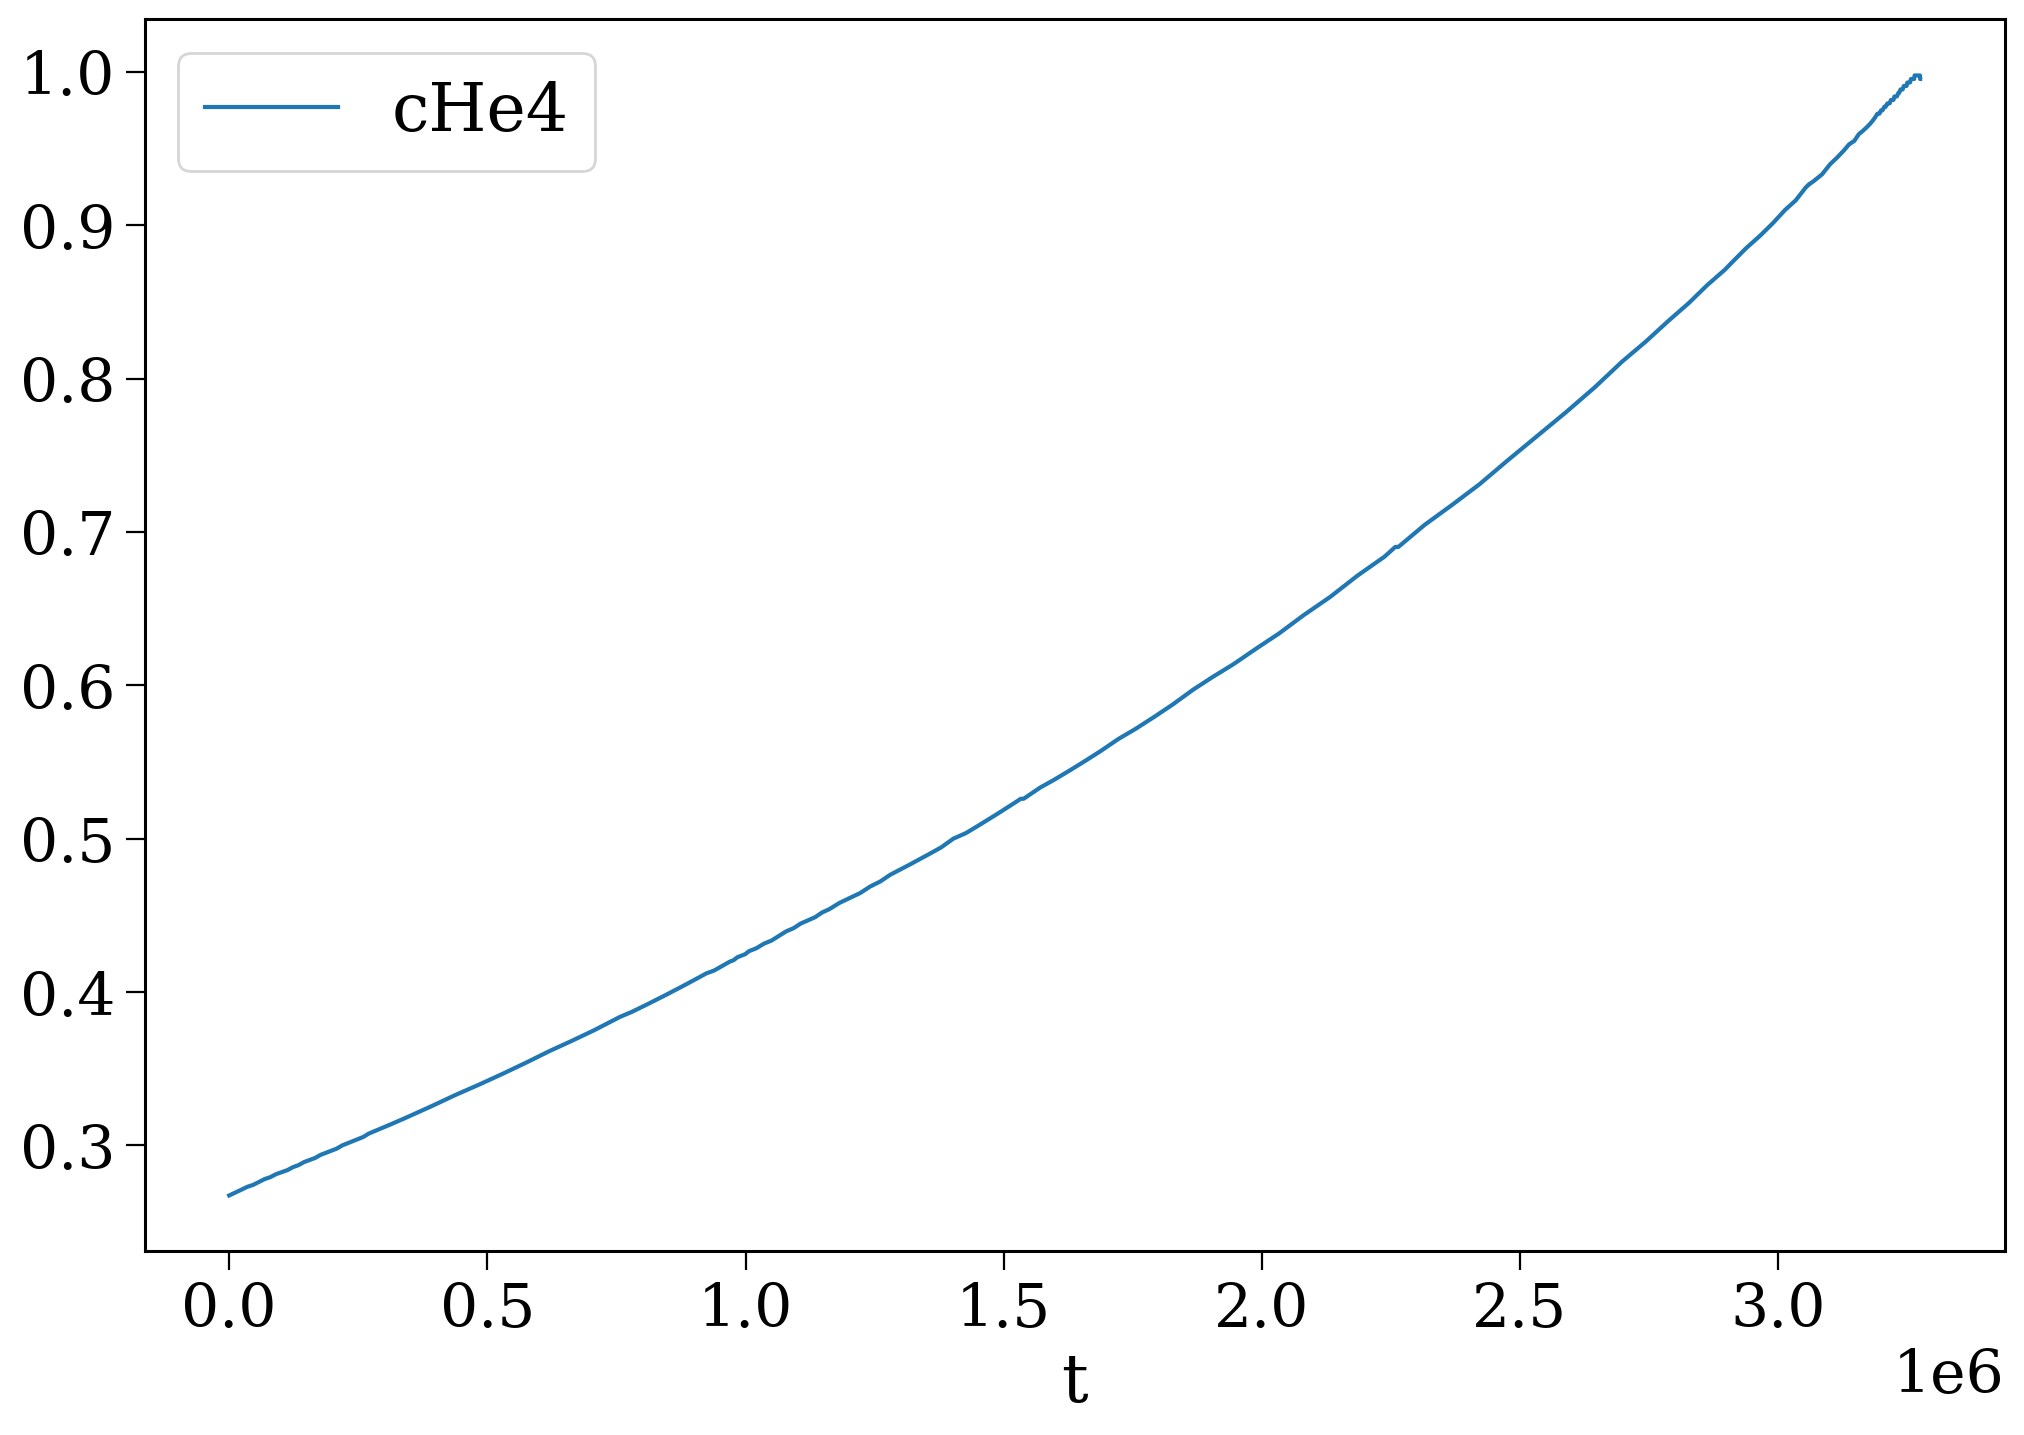

In [117]:
df.plot("t", "cHe4")

In [50]:
df = brott.read_track_dataframe("/mnt/ceph/users/twagg/dr1/brott2011_evol/", 5, 117, "mw")

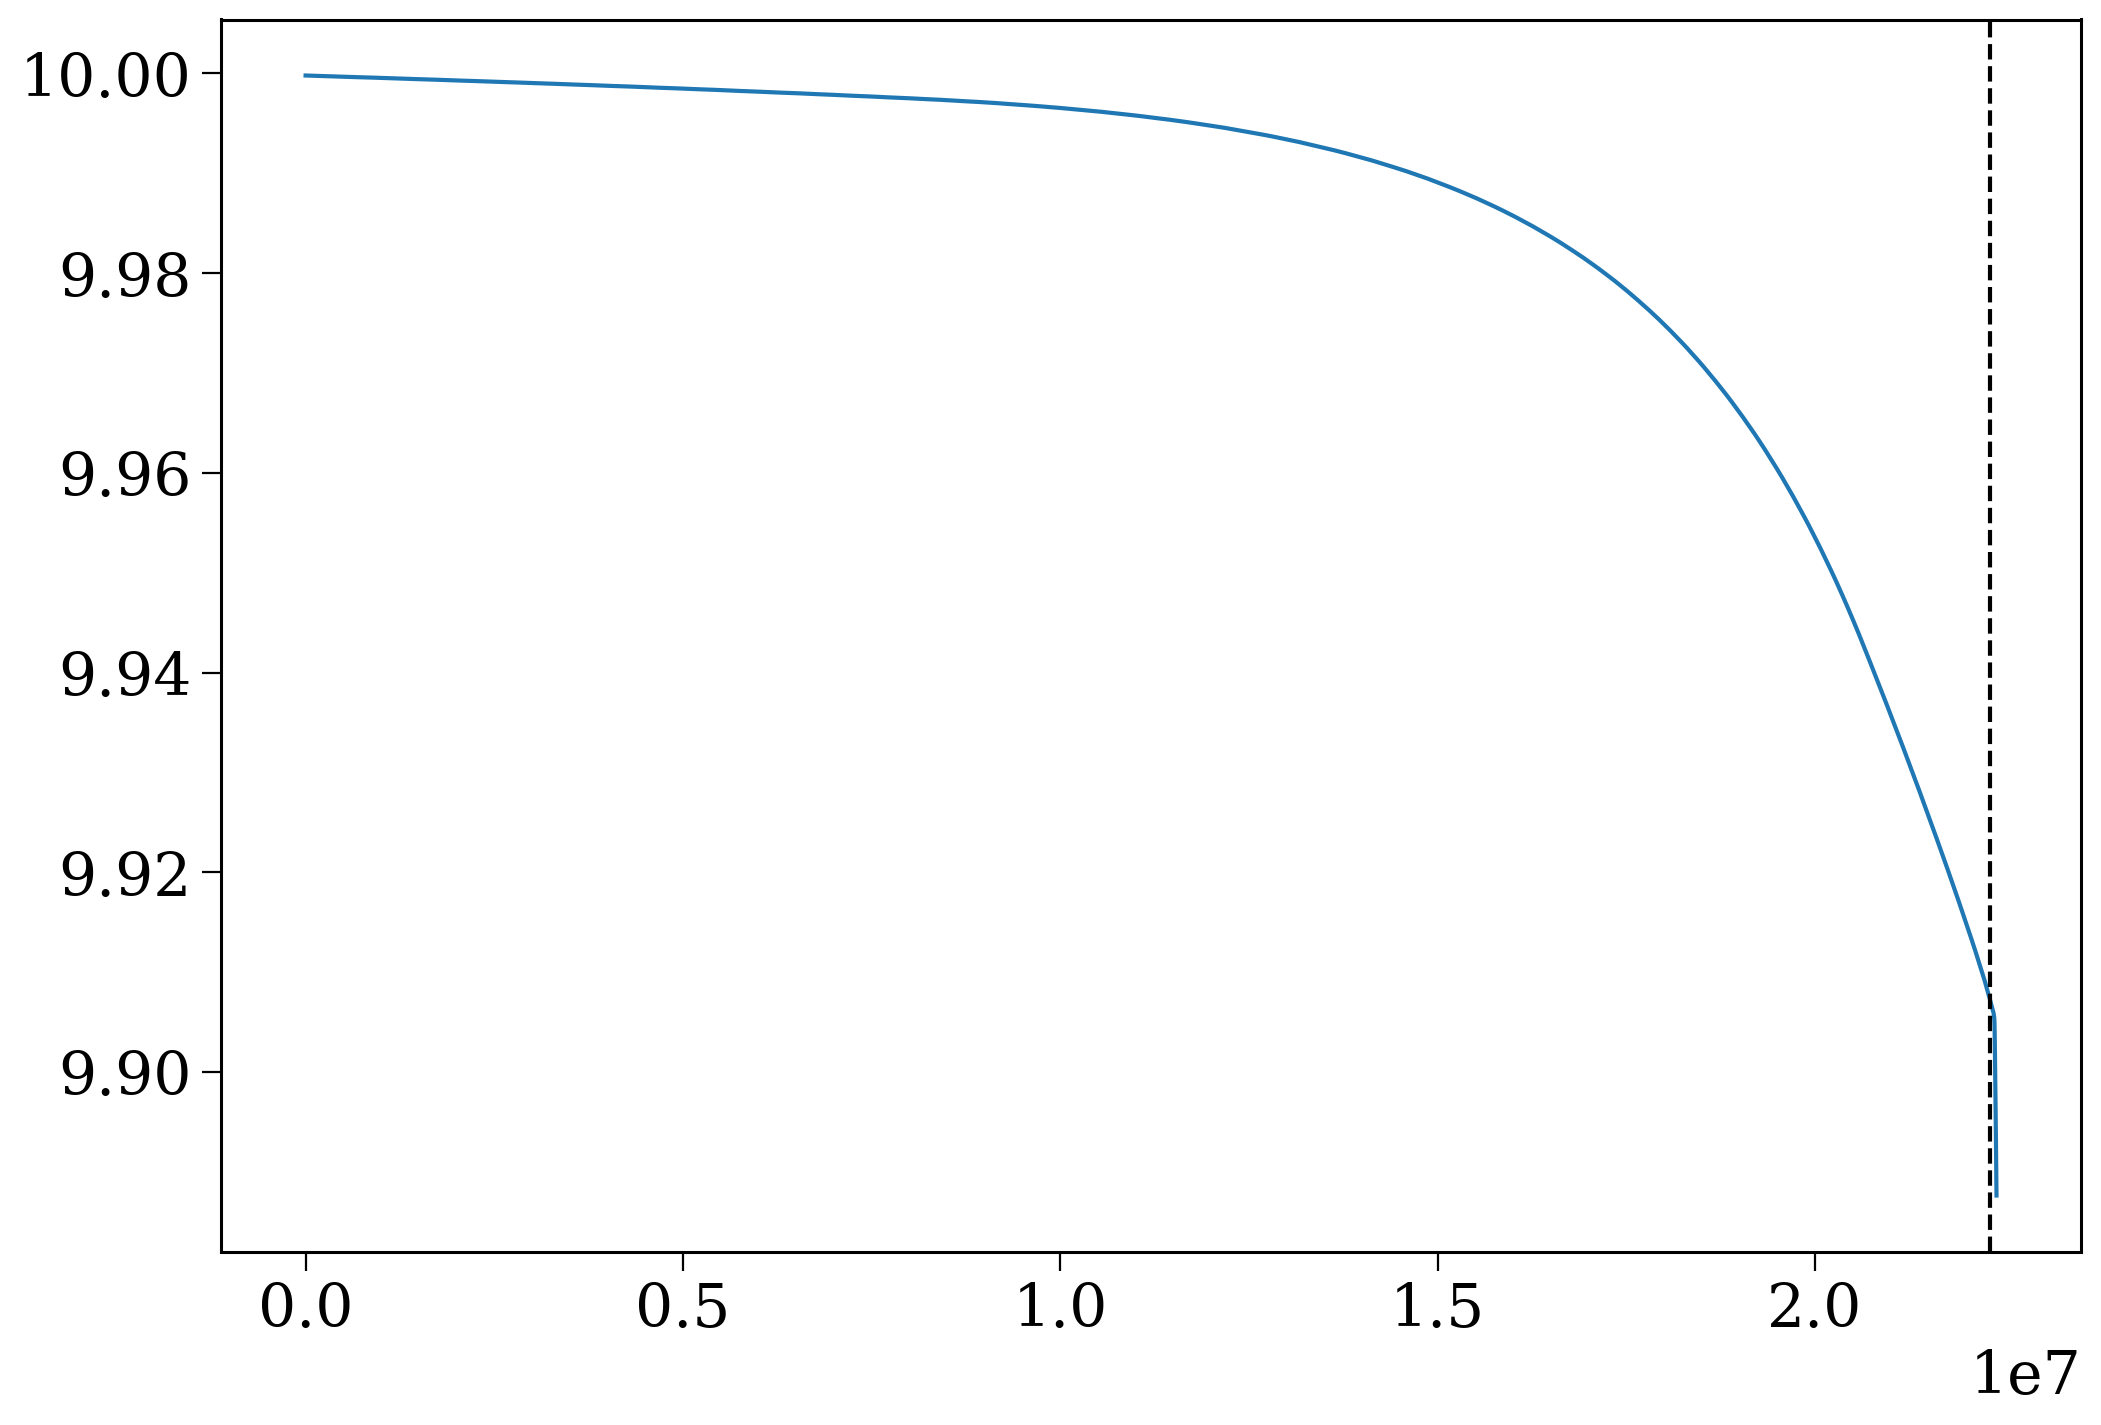

In [32]:
plt.plot(df["t"], df["Mass"])
plt.axvline(lifetime.to(u.yr).value, color="k", ls="--", label="H-burning lifetime")
# plt.xscale("log")

In [ ]:
df["t"]

,m_init,v_zams,galaxy,t,Mass,Teff,logL,R,log(Mdot),logg,Vsurf,Prot,Vcrit,Ge,eps(H),eps(He),eps(Li),eps(Be),eps(B),eps(C),eps(N),eps(O),eps(F),eps(Ne),eps(Na),eps(Mg),eps(Al),eps(Si),eps(Fe),sH1,sHe3,sHe4,sLi7,sBe9,sB10,sB11,sC12,sC13,sN14,sN15,sO16,sO17,sO18,sF19,sNe20,sNe21,sNe22,sNa23,sMg24,sMg25,sMg26,sAl26,sAl27,sSi28,sSi29,sSi30,sFe56,cH1,cHe3,cHe4,cLi7,cBe9,cB10,cB11,cC12,cC13,cN14,cN15,cO16,cO17,cO18,cF19,cNe20,cNe21,cNe22,cNa23,cMg24,cMg25,cMg26,cAl26,cAl27,cSi28,cSi29,cSi30,cFe56
0,10,0,mw,0.0,9.99978,25923.13157,3.73614,3.65634,-9.61760,4.31162,0.0,0.0,716.9440,0.01440,12.0,10.95754,3.25001,1.38001,2.70001,8.13001,7.64001,8.55001,4.56001,7.84001,6.17001,7.32001,6.37001,7.41001,7.40001,0.727394,0.000033,0.263815,8.367580e-09,1.570440e-10,7.225700e-10,3.215440e-09,0.001164,0.000014,0.000443,1.744660e-06,0.004120,0.000002,0.000009,5.017990e-07,0.000935,0.000002,0.000076,0.000025,0.000288,0.000038,0.000043,1.000000e-99,0.000046,0.000483,0.000025,0.000017,0.001023,7.128530e-01,1.306170e-06,0.277971,1.358310e-16,1.000000e-99,1.000000e-99,9.908320e-32,0.000023,7.464490e-06,0.002761,1.088930e-07,0.002655,0.000376,1.386760e-09,3.605790e-09,0.000935,0.000002,0.000030,0.000073,0.000288,0.000034,0.000045,2.301440e-06,0.000046,0.000483,0.000025,0.000017,0.001023
1,10,0,mw,117867.0,9.99975,25883.92071,3.73762,3.67371,-9.61820,4.30750,0.0,0.0,715.2290,0.01445,12.0,10.95754,3.25001,1.38001,2.70001,8.13001,7.64001,8.55001,4.56001,7.84001,6.17001,7.32001,6.37001,7.41001,7.40001,0.727394,0.000033,0.263815,8.367580e-09,1.570440e-10,7.225700e-10,3.215440e-09,0.001164,0.000014,0.000443,1.744660e-06,0.004120,0.000002,0.000009,5.017990e-07,0.000935,0.000002,0.000076,0.000025,0.000288,0.000038,0.000043,1.000000e-99,0.000046,0.000483,0.000025,0.000017,0.001023,7.112140e-01,1.312200e-06,0.280543,1.355190e-16,1.000000e-99,1.000000e-99,9.749900e-32,0.000024,7.691300e-06,0.002871,1.132400e-07,0.002529,0.000373,1.377210e-09,2.552700e-09,0.000935,0.000002,0.000027,0.000077,0.000288,0.000033,0.000046,2.382320e-06,0.000046,0.000483,0.000025,0.000017,0.001023
2,10,0,mw,234968.0,9.99972,25849.85729,3.73915,3.68986,-9.61826,4.30369,0.0,0.0,713.6420,0.01450,12.0,10.95754,3.25001,1.38001,2.70001,8.13001,7.64001,8.55001,4.56001,7.84001,6.17001,7.32001,6.37001,7.41001,7.40001,0.727394,0.000033,0.263815,8.367580e-09,1.570440e-10,7.225700e-10,3.215440e-09,0.001164,0.000014,0.000443,1.744660e-06,0.004120,0.000002,0.000009,5.017990e-07,0.000935,0.000002,0.000076,0.000025,0.000288,0.000038,0.000043,1.000000e-99,0.000046,0.000483,0.000025,0.000017,0.001023,7.079460e-01,1.312200e-06,0.282488,1.358310e-16,1.000000e-99,1.000000e-99,9.506050e-32,0.000025,7.906790e-06,0.002979,1.174900e-07,0.002415,0.000370,1.361440e-09,1.828100e-09,0.000935,0.000002,0.000024,0.000079,0.000288,0.000033,0.000046,2.426610e-06,0.000046,0.000483,0.000025,0.000017,0.001023
3,10,0,mw,351207.0,9.99970,25819.48538,3.74066,3.70501,-9.61782,4.30013,0.0,0.0,712.1620,0.01455,12.0,10.95754,3.25001,1.38001,2.70001,8.13001,7.64001,8.55001,4.56001,7.84001,6.17001,7.32001,6.37001,7.41001,7.40001,0.727394,0.000033,0.263815,8.367580e-09,1.570440e-10,7.225700e-10,3.215440e-09,0.001164,0.000014,0.000443,1.744660e-06,0.004120,0.000002,0.000009,5.017990e-07,0.000935,0.000002,0.000076,0.000025,0.000288,0.000038,0.000043,1.000000e-99,0.000046,0.000483,0.000025,0.000017,0.001023,7.063180e-01,1.309180e-06,0.284446,1.355190e-16,1.000000e-99,1.000000e-99,9.375620e-32,0.000025,8.090960e-06,0.003076,1.213390e-07,0.002307,0.000365,1.339680e-09,1.324340e-09,0.000935,0.000002,0.000022,0.000082,0.000288,0.000033,0.000046,2.449060e-06,0.000046,0.000483,0.000025,0.000017,0.001023
4,10,0,mw,466535.0,9.99967,25791.91164,3.74217,3.71939,-9.61708,4.29677,0.0,0.0,710.7650,0.01460,12.0,10.95754,3.25001,1.38001,2.70001,8.13001,7.64001,8.55001,4.56001,7.84001,6.17001,7.32001,6.37001,7.41001,7.40001,0.727394,0.000033,0.263815,8.367580e-09,1.570440e-10,7.225700e-10,3.215440e-09,0.001164,0.000014,0.000443,1.744660e-06,0.004120,0.00